# Linear SVM in Practice — Spam vs Ham

**Companion to the theory notes:** [[2SVMMotivation]] · [[4aMaximumMarginClassifier]] · [[4bSoftMarginAndC]]

We have built the intuition for **hyperplanes, margins, slack variables (`ξ`)** and the
**cost of misclassification (`C`)**. Time to use them on a real dataset.

**Goal:** classify an email as **spam (1)** or **ham (0)** with a *linear* Support
Vector Machine, then tune `C` properly.

**Dataset — UCI Spambase** (<https://archive.ics.uci.edu/dataset/94/spambase>):
- **57 features**, all continuous:
  - 48 `word_freq_*` — % of words in the email matching a given word,
  - 6 `char_freq_*` — % of characters matching a given char (`;`, `(`, `[`, `!`, `$`, `#`),
  - 3 `capital_run_length_*` — average / longest / total runs of capital letters.
- **1 target** `spam` ∈ {0 = ham, 1 = spam}.

Most features are **frequencies of words/patterns common in spam** (`free`, `money`,
`!`, `$`, …).

### Workflow
1. Load & explore the data.
2. **Standardise** (SVMs are distance-based → scale matters).
3. Train a **baseline linear SVM** (default `C`).
4. Evaluate: accuracy, confusion matrix, **sensitivity & specificity (manual)**, precision.
5. **k-fold cross-validation** with `cross_val_score()` for a reliable estimate.
6. **Grid search** over `C` to find the best generalisation.
7. Tune `C` for **different metrics**.
8. Kernel teaser → why we move to non-linear SVMs next.

## ⚠️ Read this first — `C` means the *opposite* in sklearn

In the **theory** ([[4bSoftMarginAndC]]) we attached a slack `ξ` to each point and wrote
the objective as `minimise ‖W‖²/2 + C·Σξ`. There `C` was tied directly to *how much
slack we tolerate*. But the way the lecture phrased the **normalised** `M(1−ε)` form,
and the way `sklearn` implements it, are **inverted** relative to each other:

| | A **high** `C` means… | Effect |
|---|---|---|
| **In theory** (lecture phrasing) | *allow* more misclassifications | wider margin → **more generalisable** |
| **In `sklearn.svm.SVC`** | *penalise* misclassification more | narrow margin → **more likely to overfit** |

So in **scikit-learn** (what we use below), `C` is a **regularisation strength**:

```
sklearn:  C ↑  → penalty on errors ↑ → narrow margin, hugs data → OVERFIT
          C ↓  → penalty on errors ↓ → wide margin, tolerant   → UNDERFIT / general
```

Keep this table in mind every time you read a `C` value in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             precision_score, recall_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

## 1. Load and explore the data

In [2]:
df = pd.read_csv('spam.csv')
print('shape:', df.shape)
df.head()

shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


target column: spam

Class balance:
  ham  (0):  2788  (60.6%)
  spam (1):  1813  (39.4%)


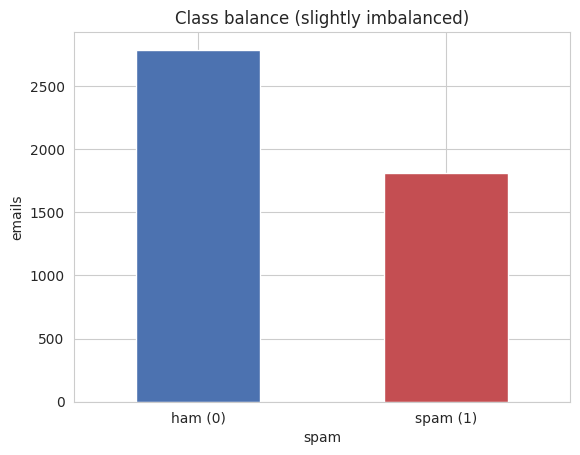

In [3]:
# target is the last column, named 'spam'
print('target column:', df.columns[-1])
counts = df['spam'].value_counts().sort_index()
print('\nClass balance:')
print(f'  ham  (0): {counts[0]:>5}  ({counts[0]/len(df):.1%})')
print(f'  spam (1): {counts[1]:>5}  ({counts[1]/len(df):.1%})')

ax = counts.rename({0: 'ham (0)', 1: 'spam (1)'}).plot(
    kind='bar', color=['#4c72b0', '#c44e52'], rot=0)
ax.set_title('Class balance (slightly imbalanced)')
ax.set_ylabel('emails')
plt.show()

The classes are **moderately imbalanced** (~61% ham / ~39% spam). That is mild enough
to train directly, but it is exactly *why accuracy alone is not enough* — we will also
look at sensitivity (spam recall) and specificity (ham recall).

features: 57


/tmp/claude-1000/ipykernel_65026/3445560051.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[col], ax=ax, showfliers=False,
/tmp/claude-1000/ipykernel_65026/3445560051.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['ham', 'spam']); ax.set_xlabel('')
/tmp/claude-1000/ipykernel_65026/3445560051.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[col], ax=ax, showfliers=False,


/tmp/claude-1000/ipykernel_65026/3445560051.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['ham', 'spam']); ax.set_xlabel('')


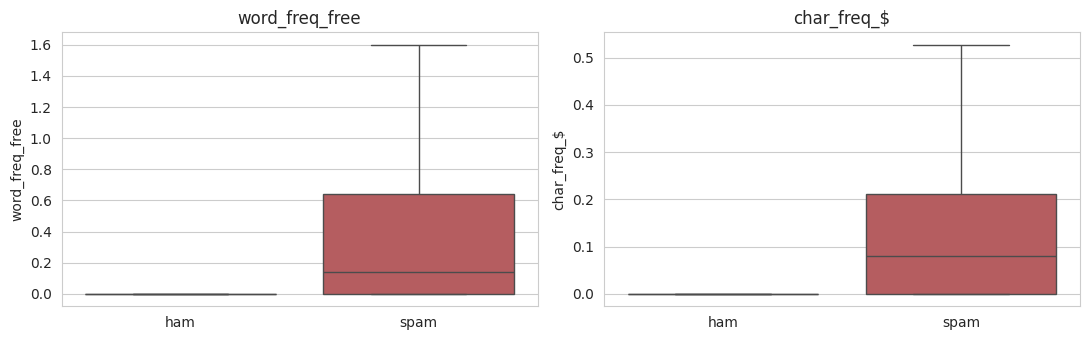

In [4]:
# split features / target
X = df.drop(columns='spam')
y = df['spam']
print('features:', X.shape[1])

# a couple of classic spam words: their frequency clearly differs by class
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col in zip(axes, ['word_freq_free', 'char_freq_$']):
    if col not in X.columns:               # char_freq_$ may be stored differently
        col = [c for c in X.columns if c.endswith('_$') or 'char_freq' in c][0]
    sns.boxplot(x=y, y=X[col], ax=ax, showfliers=False,
                palette=['#4c72b0', '#c44e52'])
    ax.set_xticklabels(['ham', 'spam']); ax.set_xlabel('')
    ax.set_title(col)
plt.tight_layout(); plt.show()

Spam emails carry the word **"free"** and the **`$`** character far more often — the
features really do separate the classes. A linear boundary should already do well.

## 2. Train/test split + standardisation

SVMs measure **distance to the hyperplane**, so a feature on a 0–100 scale would
dominate one on a 0–1 scale. We **standardise** every feature to mean 0 / variance 1.

**Leakage rule:** fit the scaler on **training data only**. We wrap the scaler and the
SVM in a `Pipeline` so that, later, cross-validation re-fits the scaler *inside each
fold* automatically.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

print('train:', X_train.shape, ' test:', X_test.shape)

# pipeline = scale  ->  linear SVM. Re-fits the scaler on each CV fold (no leakage).
baseline = make_pipeline(StandardScaler(),
                         SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))
baseline.fit(X_train, y_train)
print('baseline trained (linear kernel, default C = 1.0)')

train: (3220, 57)  test: (1381, 57)


baseline trained (linear kernel, default C = 1.0)


## 3. Baseline evaluation

Test accuracy: 0.9290


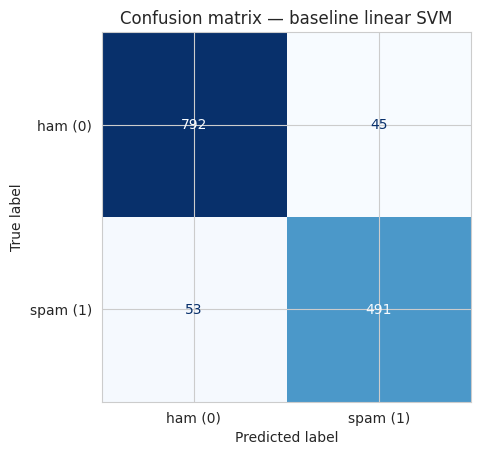

array([[792,  45],
       [ 53, 491]])

In [6]:
y_pred = baseline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}')

cm = confusion_matrix(y_test, y_pred)          # rows = actual, cols = predicted
disp = ConfusionMatrixDisplay(cm, display_labels=['ham (0)', 'spam (1)'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion matrix — baseline linear SVM'); plt.show()
cm

### Sensitivity & specificity — and why we compute specificity *by hand*

From the confusion matrix (label **spam = positive**):

```
                 predicted ham      predicted spam
actual ham   |   TN (true neg)   |   FP (false pos)   |
actual spam  |   FN (false neg)  |   TP (true pos)    |
```

- **Sensitivity / recall** = `TP / (TP + FN)` — of all real spam, how much did we catch?
- **Specificity**          = `TN / (TN + FP)` — of all real ham, how much did we keep?
- **Precision**            = `TP / (TP + FP)` — of mails flagged spam, how many truly are?

> **NOTE (from the course):** `scikit-learn` ships `recall_score`, `precision_score`,
> etc., but **no `specificity_score`** — there is no built-in function for it. So we
> compute specificity **manually** from the confusion-matrix counts:
> `specificity = TN / (TN + FP)`.

In [7]:
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)          # = recall for the spam class
specificity = TN / (TN + FP)          # <-- computed MANUALLY (no sklearn function)
precision   = TP / (TP + FP)
accuracy    = (TP + TN) / cm.sum()

print(f'TN={TN}  FP={FP}  FN={FN}  TP={TP}\n')
print(f'Accuracy      : {accuracy:.4f}')
print(f'Sensitivity   : {sensitivity:.4f}   (spam caught)        = recall_score = '
      f'{recall_score(y_test, y_pred):.4f}')
print(f'Specificity   : {specificity:.4f}   (ham kept, MANUAL)   -> no sklearn fn')
print(f'Precision     : {precision:.4f}   (flagged-spam correct) = precision_score = '
      f'{precision_score(y_test, y_pred):.4f}')

TN=792  FP=45  FN=53  TP=491

Accuracy      : 0.9290
Sensitivity   : 0.9026   (spam caught)        = recall_score = 0.9026
Specificity   : 0.9462   (ham kept, MANUAL)   -> no sklearn fn
Precision     : 0.9160   (flagged-spam correct) = precision_score = 0.9160


In [8]:
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

              precision    recall  f1-score   support

         ham       0.94      0.95      0.94       837
        spam       0.92      0.90      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.93      1381
weighted avg       0.93      0.93      0.93      1381



A single 70/30 split gives **one** number per metric. Change `random_state` and the
numbers wobble. For a **reliable** estimate we should average over several splits →
cross-validation.

## 4. k-fold cross-validation with `cross_val_score()`

`cross_val_score` trains the model on `k−1` folds and tests on the held-out fold,
rotating through all `k` folds, then returns the `k` scores. We use **stratified**
5-fold so each fold keeps the ~61/39 class ratio.

Because we pass the **pipeline**, the `StandardScaler` is re-fit *inside* every fold —
no information leaks from validation into training.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0)),
    X, y, cv=cv, scoring='accuracy')

print('fold accuracies:', np.round(cv_scores, 4))
print(f'mean = {cv_scores.mean():.4f}   std = {cv_scores.std():.4f}')
print(f'\n95%-ish range: {cv_scores.mean():.3f} ± {2*cv_scores.std():.3f}')

fold accuracies: [0.9175 0.9348 0.9272 0.9272 0.9228]
mean = 0.9259   std = 0.0057

95%-ish range: 0.926 ± 0.011


The mean cross-validated accuracy is a **far more trustworthy** estimate than the
single-split number, and the small standard deviation tells us the model is stable.

## 5. Tuning `C` with Grid Search

Picking `C = 1.0` was arbitrary. **`GridSearchCV`** evaluates a list of `C` values, each
with cross-validation, and reports the best. We sweep `C` across several orders of
magnitude.

Remember the **sklearn meaning** (inverted from theory):

```
small C → light penalty → WIDE margin  → may UNDERFIT
large C → heavy penalty → NARROW margin → may OVERFIT
```

In [10]:
param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='linear')),
    param_grid, cv=cv, scoring='accuracy',
    return_train_score=True, n_jobs=-1)
grid.fit(X_train, y_train)

print('best C       :', grid.best_params_['svc__C'])
print(f'best CV acc  : {grid.best_score_:.4f}')
print(f'test acc     : {accuracy_score(y_test, grid.predict(X_test)):.4f}')

best C       : 100
best CV acc  : 0.9264
test acc     : 0.9261


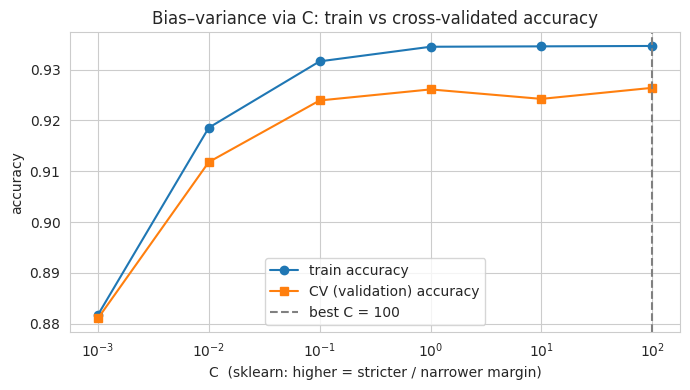

In [11]:
res = pd.DataFrame(grid.cv_results_)
Cs = [p['svc__C'] for p in res['params']]

plt.figure(figsize=(7, 4))
plt.semilogx(Cs, res['mean_train_score'], 'o-', label='train accuracy')
plt.semilogx(Cs, res['mean_test_score'],  's-', label='CV (validation) accuracy')
plt.axvline(grid.best_params_['svc__C'], color='grey', ls='--',
            label=f"best C = {grid.best_params_['svc__C']}")
plt.xlabel('C  (sklearn: higher = stricter / narrower margin)')
plt.ylabel('accuracy')
plt.title('Bias–variance via C: train vs cross-validated accuracy')
plt.legend(); plt.tight_layout(); plt.show()

Reading the curve ([[1BiasVsVariance]]):

- **Small `C` (left):** heavy regularisation, wide margin → train and CV accuracy both
  lower = **underfit / high bias**.
- **Large `C` (right):** train accuracy keeps climbing while CV accuracy stalls or dips —
  the gap is **overfitting / high variance**.
- **Best `C`:** the dashed line — the bottom of the bias–variance U, where the *validation*
  curve peaks.

## 6. Tuning `C` for *different* metrics

The "best" `C` depends on **what you optimise for**. A spam filter that wrongly junks a
real email (a false positive on ham) is costly — you may prefer **high specificity /
precision** over raw accuracy. Grid search lets us re-tune `C` per metric simply by
changing `scoring`.

In [12]:
# specificity = recall of the *ham* (label 0) class -> use a custom scorer
from sklearn.metrics import make_scorer, recall_score as _recall
specificity_scorer = make_scorer(_recall, pos_label=0)

scorings = {'accuracy': 'accuracy',
            'precision (spam)': 'precision',
            'recall/sensitivity (spam)': 'recall',
            'specificity (ham)': specificity_scorer}

rows = []
for name, scoring in scorings.items():
    g = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='linear')),
                     param_grid, cv=cv, scoring=scoring, n_jobs=-1).fit(X_train, y_train)
    rows.append({'metric': name,
                 'best C': g.best_params_['svc__C'],
                 'best CV score': round(g.best_score_, 4)})

pd.DataFrame(rows)

,metric,best C,best CV score
0,accuracy,100.000,0.9264
1,precision (spam),0.001,0.9238
2,recall/sensitivity (spam),100.000,0.9023
3,specificity (ham),0.001,0.9590


Notice the **optimal `C` shifts with the metric**. Optimising for *precision /
specificity* (don't junk real mail) can favour a different `C` than optimising for raw
*accuracy* or for *recall* (catch every spam). Choose the metric that matches the
real-world cost of each error, **then** tune `C`.

## 7. Kernel teaser — why we move on next

Everything above used `kernel='linear'`: a **straight** hyperplane. When classes are
**not** linearly separable, even the best soft-margin *line* underperforms. The **kernel
trick** lets the SVM draw curved boundaries by implicitly mapping features into a
higher-dimensional space — without computing that space explicitly.

A quick comparison on this same data (`rbf` = Gaussian kernel):

In [13]:
for kern in ['linear', 'rbf']:
    s = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel=kern, C=1.0)),
                        X, y, cv=cv, scoring='accuracy')
    print(f'{kern:>6} kernel  ->  CV accuracy {s.mean():.4f} ± {s.std():.4f}')

linear kernel  ->  CV accuracy 0.9259 ± 0.0057


   rbf kernel  ->  CV accuracy 0.9322 ± 0.0045


On Spambase the data is *already* fairly linearly separable, so the gain is modest —
but on genuinely non-linear problems the kernel SVM is far stronger. **Next module:**
kernels (`rbf`, polynomial), the `gamma` hyperparameter, and tuning `C` **and** `gamma`
together.

## Summary

```
LINEAR SVM ON SPAMBASE — what we did
------------------------------------
1. Standardise features            (SVMs are distance-based → scale matters)
2. Baseline SVC(kernel='linear', C=1)  → ~93% test accuracy
3. Metrics beyond accuracy:
      sensitivity = TP/(TP+FN)   (spam caught)      -> recall_score
      specificity = TN/(TN+FP)   (ham kept)         -> MANUAL (no sklearn fn)
      precision   = TP/(TP+FP)   (flags correct)    -> precision_score
4. cross_val_score (stratified 5-fold) → reliable, stable accuracy estimate
5. GridSearchCV over C → bias-variance U-curve, pick best generalisation
6. Re-tune C per metric → best C shifts with what you optimise for

C — MIND THE INVERSION
   theory  : high C = allow more errors = more generalisable
   sklearn : high C = penalise errors  = narrow margin = OVERFIT risk

NEXT: non-linear data → the KERNEL trick (rbf / poly) + gamma.
```

**See also:** [[4aMaximumMarginClassifier]] · [[4bSoftMarginAndC]] · [[1BiasVsVariance]]